In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

df = pd.read_csv('../data/processed/application_train_features.csv')

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Default rate in train:", round(y_train.mean() * 100, 2), "%")
print("Default rate in test:", round(y_test.mean() * 100, 2), "%")

Training set: (246008, 123)
Test set: (61503, 123)
Default rate in train: 8.07 %
Default rate in test: 8.07 %


In [2]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
lr_auroc = roc_auc_score(y_test, lr_proba)
lr_gini = 2 * lr_auroc - 1
ks_stat = max(tpr - fpr)

print("Logistic Regression Results:")
print(f"AUROC : {lr_auroc:.4f}")
print(f"Gini  : {lr_gini:.4f}")
print(f"KS    : {ks_stat:.4f}")

Logistic Regression Results:
AUROC : 0.7462
Gini  : 0.4924
KS    : 0.3649


In [3]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_auroc = roc_auc_score(y_test, xgb_proba)
xgb_gini = 2 * xgb_auroc - 1
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
xgb_ks = max(tpr_xgb - fpr_xgb)

print("XGBoost Results:")
print(f"AUROC : {xgb_auroc:.4f}")
print(f"Gini  : {xgb_gini:.4f}")
print(f"KS    : {xgb_ks:.4f}")

XGBoost Results:
AUROC : 0.7615
Gini  : 0.5230
KS    : 0.3864


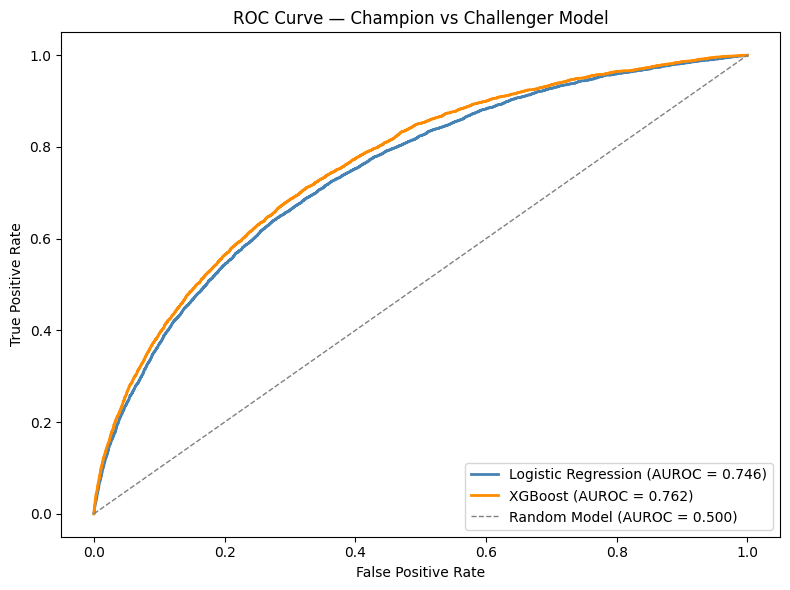

ROC curve saved to reports folder


In [4]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, 
         label=f'Logistic Regression (AUROC = {lr_auroc:.3f})', 
         color='steelblue', linewidth=2)

plt.plot(fpr_xgb, tpr_xgb, 
         label=f'XGBoost (AUROC = {xgb_auroc:.3f})', 
         color='darkorange', linewidth=2)

plt.plot([0, 1], [0, 1], 
         label='Random Model (AUROC = 0.500)', 
         color='gray', linewidth=1, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Champion vs Challenger Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

print("ROC curve saved to reports folder")

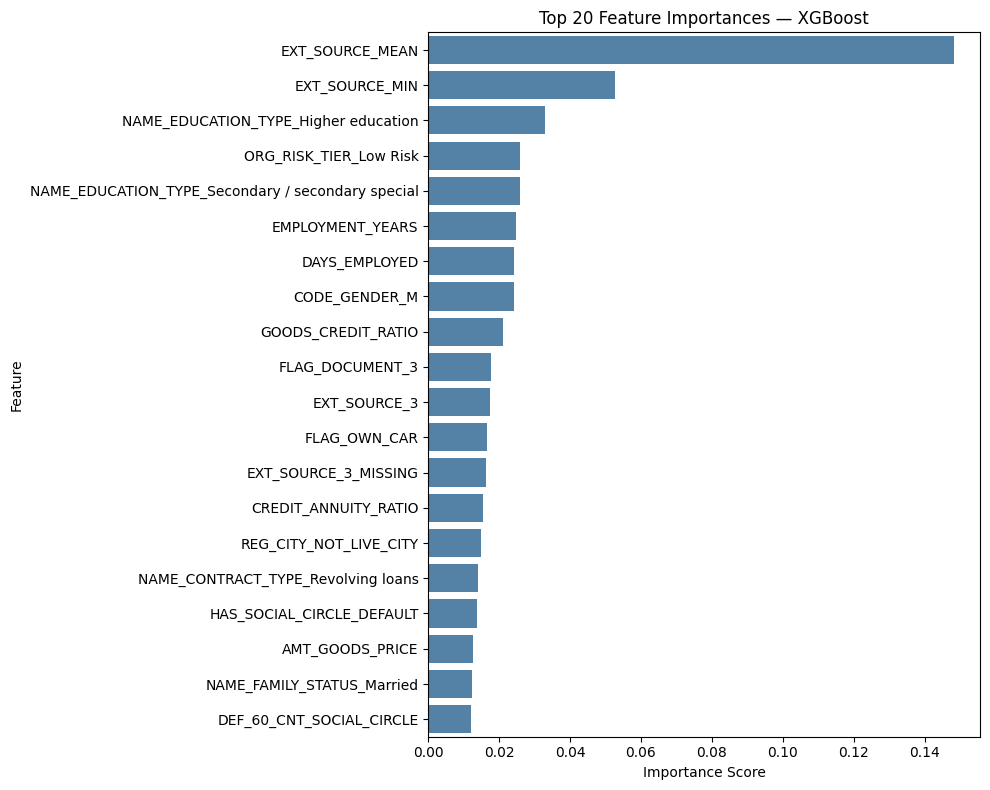


Top 10 most important features:
                                          feature  importance
                                  EXT_SOURCE_MEAN    0.148243
                                   EXT_SOURCE_MIN    0.052640
             NAME_EDUCATION_TYPE_Higher education    0.033016
                           ORG_RISK_TIER_Low Risk    0.025772
NAME_EDUCATION_TYPE_Secondary / secondary special    0.025749
                                 EMPLOYMENT_YEARS    0.024792
                                    DAYS_EMPLOYED    0.024073
                                    CODE_GENDER_M    0.024067
                               GOODS_CREDIT_RATIO    0.021118
                                  FLAG_DOCUMENT_3    0.017665


In [5]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x='importance', y='feature', color='steelblue')
plt.title('Top 20 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(importance.head(10).to_string(index=False))